In [ ]:
# Installing required libraries for the notebook.
!pip install ghapi
!pip install pandas
!pip install matplotlib
!pip install tensorflow_hub
!pip install tensorflow_datasets
!pip install contractions
!pip install tf_keras
!pip install scikit-learn

In [ ]:
# Storing the GitHub token in an environment variable for authentication with the GitHub API.
import os
os.environ["GITHUB_TOKEN"] = ""

In [ ]:
from ghapi.all import GhApi
import csv

# Creating a mapping of GitHub labels to simplified categories for classification.
labels = {
    "00 - Bug": "Bug",
    "01 - Enhancement": "Enhancement",
    "04 - Documentation": "Documentation",
    "05 - Testing": "Testing"
}

# Function to fetch closed pull requests from a specified GitHub repository and save them to a CSV file, while filtering out backport PRs and those created by bots.
def get_prs(owner, repo, token = os.environ["GITHUB_TOKEN"]):
    api = GhApi(token=token, repo=repo, owner=owner)
    result = api.pulls.list(owner=owner, repo=repo, state="closed", page=1, per_page=100)
    for page in range(2, api.last_page() + 1):
        result.extend(api.pulls.list(owner=owner, repo=repo, state="closed", page=page, per_page=100))
    
    # Save the pull request data to a CSV file, filtering out backport PRs and those created by bots.
    with open("pull_requests.csv", "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["id", "label", "title", "body"])
        for i, pr in enumerate(result):  
            label = ""
            body = pr.body or ""                                                                                                                         
            if body.strip().lower().startswith("backport") or pr.title.strip().lower().startswith("backport"):                                                                                   
                continue    
            if pr.user.type == "Bot":                                                                                                                      
                continue  
            if pr.labels is None:                                                                                                                             
                continue
            for l in pr.labels:
                if l.name in labels:
                    label = labels[l.name]
                    break
            body = pr.body[:10000] if pr.body else "" # Truncate body to 10,000 characters
            writer.writerow([i+1, label, pr.title, body])
get_prs("numpy", "numpy")

In [ ]:
import re
import contractions 
import pandas as pd

def expand_contractions(text):
    return contractions.fix(text)

def remove_code_blocks(text):
    text = re.sub(r'```.*?```', '', text, flags=re.DOTALL)
    return text
    
def remove_urls(text):
    return re.sub(r'http\S+', '', text)

def remove_html_tags(text):
    return re.sub(r'<[^>]+>', '', text)

def remove_special_characters(text):
    text = re.sub(r'[^A-Za-z0-9\s]+', '', text)
    return text

def to_lowercase(text):
    return text.lower() 

# Function to preprocess pull request data by cleaning the title and body, 
# removing code blocks, expanding contractions, and performing other text 
# normalization steps to prepare the data for machine learning models.
def preprocess_pr(title, body, max_body_length = 1500):
    # Clean the title by removing common prefixes and trimming whitespace, then combine it with the body for further preprocessing.
    clean_title = re.sub(r'^[A-Z]{2,5}:\s*', '', title).strip()
    text = f"{clean_title} {body}"
    if body:
        text = remove_code_blocks(text)
        text = expand_contractions(text)
        text = remove_html_tags(text)
        text = remove_urls(text)
        text = remove_special_characters(text)
        text = re.sub(r'\s+', ' ', text)
        text = to_lowercase(text)
        body = text[:max_body_length]
    else:
        body = ""
    return f"{text}"


filename = "pull_requests.csv"
pull_requests_df = pd.read_csv(filename, engine="python")
pull_requests_df = pull_requests_df.dropna(how='any')


pull_requests_df['model_input'] = pull_requests_df.apply(lambda x: preprocess_pr(x['title'], x['body']), axis=1)

# Encoding labels to numeric values for machine learning models, where 'Bug' is encoded as 0,
# 'Enhancement' as 1, 'Documentation' as 2, and 'Testing' as 3. 
# The preprocessed data is then saved to a new CSV file for further analysis and model training.
pull_requests_df['label_encoded'] = pull_requests_df['label'].map({'Bug': 0, 'Enhancement': 1, 'Documentation': 2, 'Testing': 3})
pull_requests_df = pull_requests_df[['id','label_encoded', 'model_input']]
pull_requests_df.to_csv("pull_requests_preprocessed.csv", index=False)

In [ ]:
import tensorflow_hub as hub
import tensorflow as tf
import tf_keras                                                                                                                                

# Load the pretrained embedding model from Tensorflow Hub.                                                                        
embed = hub.KerasLayer(                                           
    "https://www.kaggle.com/models/google/nnlm/tensorFlow2/en-dim50/1",                                                    
    input_shape=[], dtype=tf.string,
    trainable=True
)
# Create a sequential model in TensorFlowKeras with the loaded pretrained embedding layer
model = tf_keras.Sequential()
model.add(embed)
model.add(tf_keras.layers.Dense(16, activation='relu'))
model.add(tf_keras.layers.Dropout(0.4))
model.add(tf_keras.layers.Dense(4, activation='softmax'))
# Compile model with Adam optimizer, sparse categorical crossentropy loss function, and accuracy as the evaluation metric.
model.compile(
    optimizer="Adam",
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer (KerasLayer)    (None, 50)                48190600  
                                                                 
 dense (Dense)               (None, 16)                816       
                                                                 
 dropout (Dropout)           (None, 16)                0         
                                                                 
 dense_1 (Dense)             (None, 4)                 68        
                                                                 
Total params: 48191484 (183.84 MB)
Trainable params: 48191484 (183.84 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
import time 
# Configure early stopping to terminate training when the validation loss does not improve for 2 consecutive epochs,
# and to restore the best weights from the epoch with the lowest validation loss.                               
early_stop = tf_keras.callbacks.EarlyStopping(   
    monitor='val_loss',                                                                                                                                   
    patience=2,                                                                                                                                           
    restore_best_weights=True                                                                                                                             
)   

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from sklearn.utils import resample
from sklearn.metrics import classification_report                                                                                                         
import tensorflow_hub as hub

                                                                                                                                                       
bug_df = pull_requests_df[pull_requests_df['label_encoded'] == 0]  
enhancement_df = pull_requests_df[pull_requests_df['label_encoded'] == 1]
documentation_df = pull_requests_df[pull_requests_df['label_encoded'] == 2]
testing_df = pull_requests_df[pull_requests_df['label_encoded'] == 3]   

print(len(bug_df), len(enhancement_df), len(documentation_df), len(testing_df))

# Upsample minority classes (Enhancement and Testing) to match the 
# number of samples in the majority class (Bug) using resampling with replacement. 
enhancement_upsampled = resample(
    enhancement_df,
    n_samples=len(bug_df),  # match majority class
    replace=True,           # sample with replacement
    random_state=42
)

testing_upsampled = resample(
    testing_df,
    n_samples=len(bug_df),  # match majority class
    replace=True,           # sample with replacement
    random_state=42
)

balanced_df = pd.concat([bug_df, enhancement_upsampled, documentation_df, testing_upsampled])
balanced_df = balanced_df.sample(frac=1, random_state=42)  

# Split the balanced dataset into training and testing sets, using stratified sampling to preserve class proportions
X_train, X_test, y_train, y_test = train_test_split(
    balanced_df['model_input'].to_numpy(),
    balanced_df['label_encoded'].to_numpy(),
    test_size=0.2,
    random_state=42,
    stratify=balanced_df['label_encoded'].to_numpy()  # preserves class proportions
)

# Compute class weights to handle any remaining class imbalance in the training data,
# which can help improve model performance by giving more importance to minority classes during training.
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))

# Train model with the training data and monitor training time.
start = time.time()
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)
print(f"NNLM 50 training time: {time.time() - start:.1f}s")


2371 1582 2416 603
Epoch 1/10
60/60 [==============================] - 9s 126ms/step - loss: 1.3212 - accuracy: 0.3740 - val_loss: 1.1969 - val_accuracy: 0.5960
Epoch 2/10
60/60 [==============================] - 7s 113ms/step - loss: 1.0709 - accuracy: 0.5987 - val_loss: 0.8888 - val_accuracy: 0.7644
Epoch 3/10
60/60 [==============================] - 6s 96ms/step - loss: 0.7920 - accuracy: 0.7277 - val_loss: 0.6471 - val_accuracy: 0.8221
Epoch 4/10
60/60 [==============================] - 6s 101ms/step - loss: 0.5867 - accuracy: 0.8107 - val_loss: 0.5021 - val_accuracy: 0.8484
Epoch 5/10
60/60 [==============================] - 7s 119ms/step - loss: 0.4528 - accuracy: 0.8543 - val_loss: 0.4260 - val_accuracy: 0.8604
Epoch 6/10
60/60 [==============================] - 7s 117ms/step - loss: 0.3561 - accuracy: 0.8926 - val_loss: 0.3744 - val_accuracy: 0.8709
Epoch 7/10
60/60 [==============================] - 7s 112ms/step - loss: 0.2888 - accuracy: 0.9159 - val_loss: 0.3481 - val_accur

60/60 [==============================] - 1s 7ms/step
=== NNLM 50D ===
               precision    recall  f1-score   support

          Bug       0.83      0.83      0.83       474
  Enhancement       0.85      0.88      0.86       474
Documentation       0.93      0.86      0.89       484
      Testing       0.93      0.97      0.95       474

     accuracy                           0.88      1906
    macro avg       0.88      0.88      0.88      1906
 weighted avg       0.88      0.88      0.88      1906



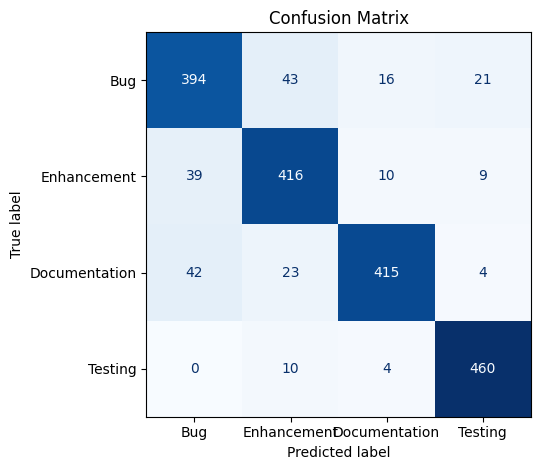

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Use the trained model to predict classes of the test set
# Evaluate the model's performance by generating a classification report and using a confusion matrix to visualize the results.
y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1) 
labels = ['Bug', 'Enhancement', 'Documentation', 'Testing']
cm = confusion_matrix(y_test, y_pred_classes)

print("=== NNLM 50D ===")                                                                                                                                
print(classification_report(y_test, y_pred_classes, target_names=labels))  

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# Loads pretrained embedding model from TensorFlow Hub with 128-dimensional embeddings,
# and creates a new sequential model using this embedding layer followed by dense layers for classification. 
embed2 = hub.KerasLayer(
    "https://www.kaggle.com/models/google/nnlm/TensorFlow2/en-dim128/1",
    input_shape=[], 
    dtype=tf.string, 
    trainable=True
)

model2 = tf_keras.Sequential()
model2.add(embed2)
model2.add(tf_keras.layers.Dense(16, activation='relu'))
model2.add(tf_keras.layers.Dropout(0.4))
model2.add(tf_keras.layers.Dense(4, activation='softmax'))

model2.compile(
    optimizer="Adam",
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model2.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_2 (KerasLayer)  (None, 128)               124642688 
                                                                 
 dense_4 (Dense)             (None, 16)                2064      
                                                                 
 dropout_2 (Dropout)         (None, 16)                0         
                                                                 
 dense_5 (Dense)             (None, 4)                 68        
                                                                 
Total params: 124644820 (475.48 MB)
Trainable params: 124644820 (475.48 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
# Train model with the training data and monitor training time.
start = time.time()
history2 = model2.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)
print(f"NNLM 128 training time: {time.time() - start:.1f}s")


Epoch 1/10
60/60 [==============================] - 85s 1s/step - loss: 1.2165 - accuracy: 0.4809 - val_loss: 0.9775 - val_accuracy: 0.7671
Epoch 2/10
60/60 [==============================] - 64s 1s/step - loss: 0.8428 - accuracy: 0.7147 - val_loss: 0.6373 - val_accuracy: 0.8447
Epoch 3/10
60/60 [==============================] - 53s 880ms/step - loss: 0.5718 - accuracy: 0.8157 - val_loss: 0.4481 - val_accuracy: 0.8688
Epoch 4/10
60/60 [==============================] - 59s 986ms/step - loss: 0.4172 - accuracy: 0.8708 - val_loss: 0.3651 - val_accuracy: 0.8851
Epoch 5/10
60/60 [==============================] - 58s 964ms/step - loss: 0.3100 - accuracy: 0.9118 - val_loss: 0.3321 - val_accuracy: 0.8919
Epoch 6/10
60/60 [==============================] - 58s 957ms/step - loss: 0.2301 - accuracy: 0.9360 - val_loss: 0.3097 - val_accuracy: 0.8966
Epoch 7/10
60/60 [==============================] - 55s 919ms/step - loss: 0.1720 - accuracy: 0.9546 - val_loss: 0.3100 - val_accuracy: 0.8940
Epoch

60/60 [==============================] - 3s 44ms/step
=== NNLM 128 ===
               precision    recall  f1-score   support

          Bug       0.85      0.85      0.85       474
  Enhancement       0.87      0.88      0.88       474
Documentation       0.93      0.88      0.91       484
      Testing       0.93      0.98      0.95       474

     accuracy                           0.90      1906
    macro avg       0.90      0.90      0.90      1906
 weighted avg       0.90      0.90      0.90      1906



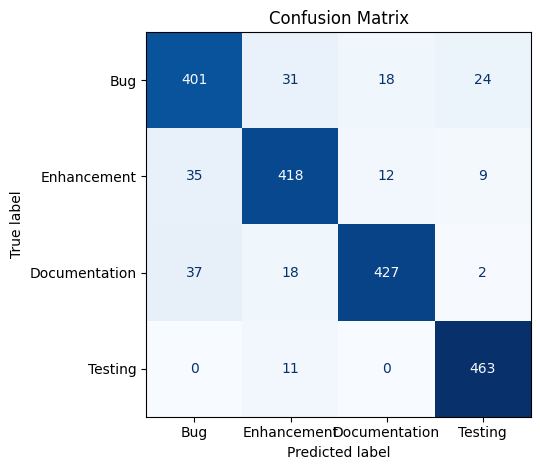

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Use the trained model to predict classes of the test set
# Evaluate the model's performance by generating a classification report and using a confusion matrix to visualize the results.

y_pred = model2.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1) 
cm = confusion_matrix(y_test, y_pred_classes)
labels = ['Bug', 'Enhancement', 'Documentation', 'Testing']

print("=== NNLM 128 ===")                                                                                                                                
print(classification_report(y_test, y_pred_classes, target_names=labels))  

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# Load pretrained embedding model from TensorFlow Hub with 50-dimensional embeddings and normalization,                                                                                                                            
embed3 = hub.KerasLayer(
    "https://www.kaggle.com/models/google/nnlm/TensorFlow2/en-dim50-with-normalization/1",
    input_shape=[], 
    dtype=tf.string, 
    trainable=True
)

model3 = tf_keras.Sequential()
model3.add(embed3)
model3.add(tf_keras.layers.Dense(16, activation='relu'))
model3.add(tf_keras.layers.Dropout(0.4))
model3.add(tf_keras.layers.Dense(4, activation='softmax'))

model3.compile(
    optimizer="Adam",
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model3.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_3 (KerasLayer)  (None, 50)                48190600  
                                                                 
 dense_6 (Dense)             (None, 16)                816       
                                                                 
 dropout_3 (Dropout)         (None, 16)                0         
                                                                 
 dense_7 (Dense)             (None, 4)                 68        
                                                                 
Total params: 48191484 (183.84 MB)
Trainable params: 48191484 (183.84 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
# Train model with the training data and monitor training time.
start = time.time()
history3 = model3.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)
print(f"NNLM 50D with normalization training time: {time.time() - start:.1f}s")

Epoch 1/10
60/60 [==============================] - 10s 162ms/step - loss: 1.3577 - accuracy: 0.3175 - val_loss: 1.2749 - val_accuracy: 0.5052
Epoch 2/10
60/60 [==============================] - 8s 133ms/step - loss: 1.1861 - accuracy: 0.4925 - val_loss: 1.0347 - val_accuracy: 0.6369
Epoch 3/10
60/60 [==============================] - 5s 88ms/step - loss: 0.9285 - accuracy: 0.6487 - val_loss: 0.7753 - val_accuracy: 0.7592
Epoch 4/10
60/60 [==============================] - 7s 116ms/step - loss: 0.7104 - accuracy: 0.7470 - val_loss: 0.5900 - val_accuracy: 0.8290
Epoch 5/10
60/60 [==============================] - 6s 93ms/step - loss: 0.5424 - accuracy: 0.8167 - val_loss: 0.4688 - val_accuracy: 0.8583
Epoch 6/10
60/60 [==============================] - 5s 89ms/step - loss: 0.4254 - accuracy: 0.8621 - val_loss: 0.3973 - val_accuracy: 0.8730
Epoch 7/10
60/60 [==============================] - 6s 97ms/step - loss: 0.3414 - accuracy: 0.8943 - val_loss: 0.3621 - val_accuracy: 0.8851
Epoch 8/1

60/60 [==============================] - 0s 6ms/step
=== NNLM 50D with normalization ===
               precision    recall  f1-score   support

          Bug       0.86      0.84      0.85       474
  Enhancement       0.87      0.89      0.88       474
Documentation       0.92      0.89      0.90       484
      Testing       0.94      0.98      0.96       474

     accuracy                           0.90      1906
    macro avg       0.90      0.90      0.90      1906
 weighted avg       0.90      0.90      0.90      1906



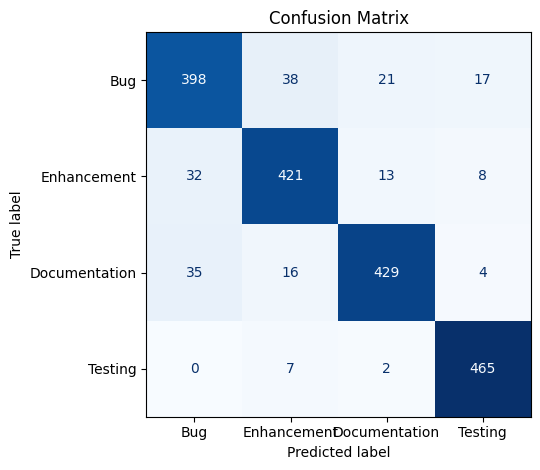

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Use the trained model to predict classes of the test set
# Evaluate the model's performance by generating a classification report and using a confusion matrix to visualize the results.

y_pred = model3.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1) 
cm = confusion_matrix(y_test, y_pred_classes)
labels = ['Bug', 'Enhancement', 'Documentation', 'Testing']

print("=== NNLM 50D with normalization ===")                                                                                                                                
print(classification_report(y_test, y_pred_classes, target_names=labels))  

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

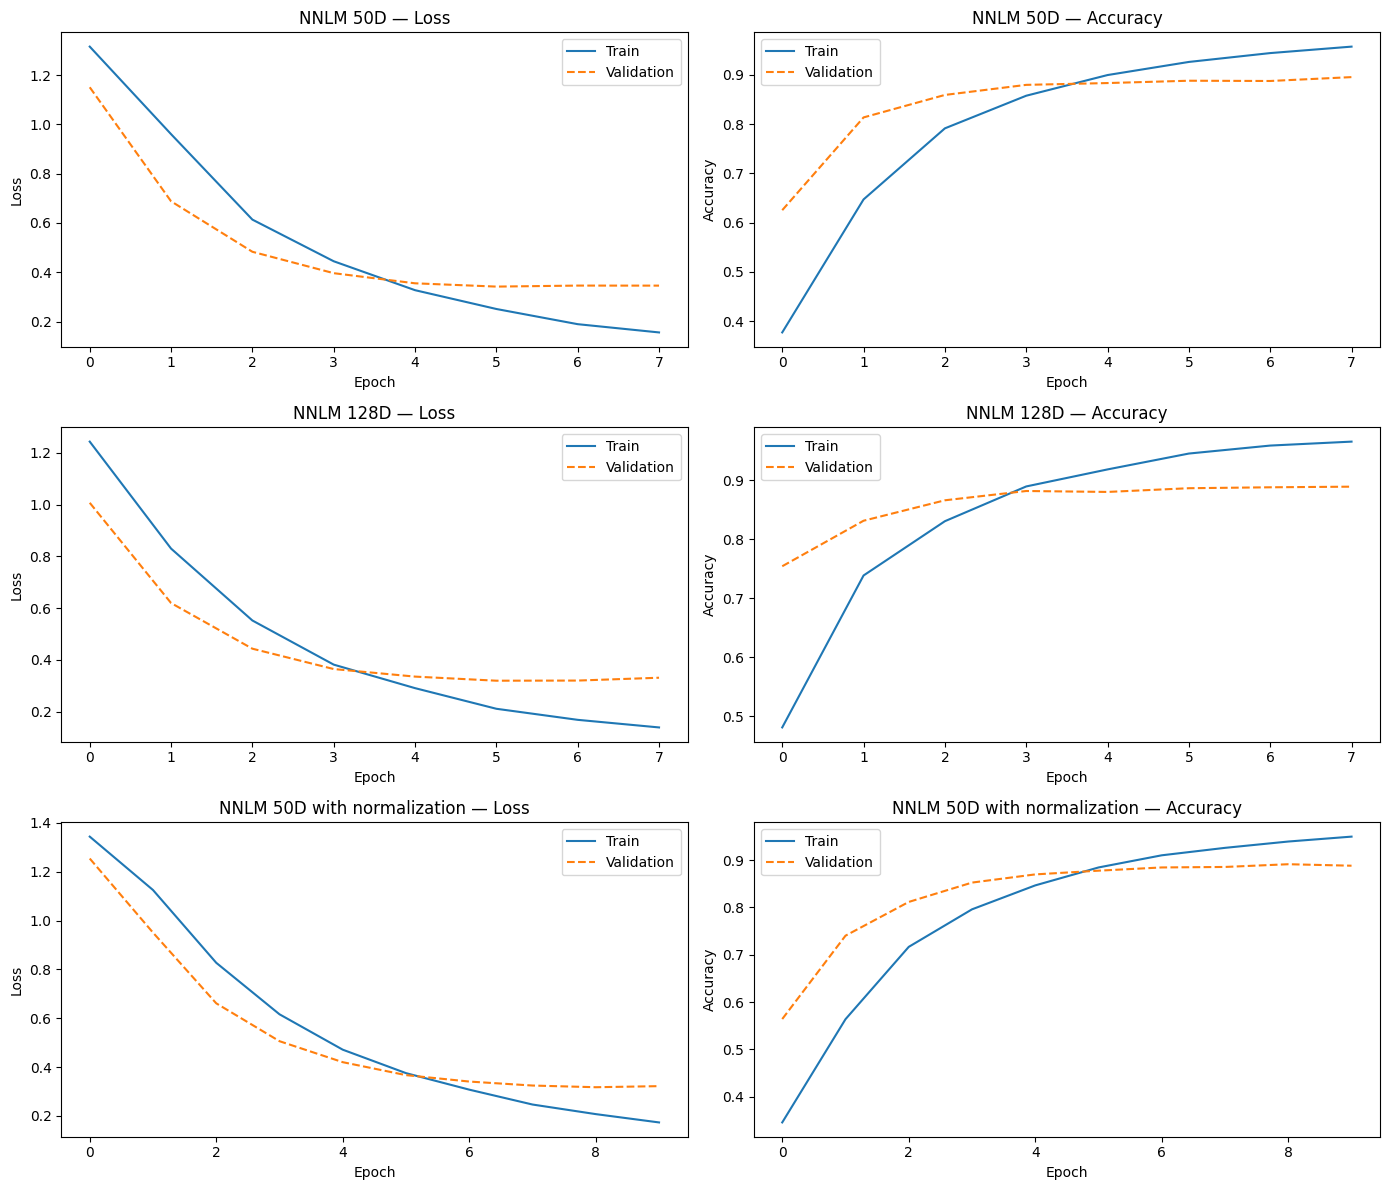

In [ ]:
# Use Matplotlib to plot the training and validation loss and accuracy curves for all three models

forig, axes = plt.subplots(3, 2, figsize=(14, 12)) 

models = [                                                                                                                                                
    (history, 'NNLM 50D'),                                                                                                                               
    (history2, 'NNLM 128D'),                                                                                                                               
    (history3, 'NNLM 50D with normalization'),            
]

for i, (hist, name) in enumerate(models):
    # Loss
    axes[i, 0].plot(hist.history['loss'], label='Train')
    axes[i, 0].plot(hist.history['val_loss'], label='Validation', linestyle='--')
    axes[i, 0].set_title(f'{name} — Loss')
    axes[i, 0].set_xlabel('Epoch')
    axes[i, 0].set_ylabel('Loss')
    axes[i, 0].legend()

      # Accuracy
    axes[i, 1].plot(hist.history['accuracy'], label='Train')
    axes[i, 1].plot(hist.history['val_accuracy'], label='Validation', linestyle='--')
    axes[i, 1].set_title(f'{name} — Accuracy')
    axes[i, 1].set_xlabel('Epoch')
    axes[i, 1].set_ylabel('Accuracy')
    axes[i, 1].legend()

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150)
plt.show()